# Lecture 14 - Exercise - Explore the $\gamma$-Ray Burst dataset

In [527]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

import os
import time
import corner
import requests
import numpy                        as np
import matplotlib                   as mpl
import matplotlib.pyplot            as plt
import matplotlib.patches           as patches
from   matplotlib                   import rc
from   matplotlib.colors            import to_hex
from   mpl_toolkits.axes_grid1      import make_axes_locatable
from   sys                          import stdout
from   scipy                        import stats, integrate
from   astroML                      import stats as astroMLstats
from   astropy.visualization.hist   import hist  as fancyhist
from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap
from   sklearn.cluster              import KMeans
from   sklearn.neighbors            import KNeighborsClassifier
from   sklearn.metrics              import confusion_matrix, accuracy_score
from   sklearn.model_selection      import train_test_split
from   sklearn.linear_model         import LogisticRegression
from   sklearn.mixture              import GaussianMixture
from   sklearn.decomposition        import PCA

#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

D:\Documents\University\Magistrale\Statistics\GitHub\working


In [528]:
#-------------------------------------------------------------------------
# Download file
#-------------------------------------------------------------------------

r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

#-------------------------------------------------------------------------
# Read content

data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

#-------------------------------------------------------------------------
# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

for name in names:
    print(name)

print()
print(data.shape)

GRB_name
GRB_name_Fermi
T0
ra
decl
pos_error
T90
T90_error
T90_start
fluence
fluence_error
redshift
'T100'
GBM_located
mjd_(T0)

(15, 8722)


Reading the documentation, the first two columns data[0], data[1] are just names according to two different convention (no physics involved). 

(RA = right ascension, DECL = declination, pos_error) indicate the two angular positions of the burst and the error on this localisation.

T0 = Earliest UTC time at which activity was reported from the GRB. This time corresponds to the earliest trigger time of the satellites or the start of the T90 interval if it preceeds those trigger time. (probably, not that relevant physically)

T90_start = UTC time that marks the start of the T90 interval. (probably, also not that relevant physically)

(T90, T90_error) = Duration of the time interval during which 90% of the GRB photon counts are observed, starting at 5% and ending at 95%; and the estimated 1σ error on the duration of the T90 interval.

T100 = Total time during which the GRB was observed. In practice, this variable is obtained by subtracting the earliest trigger time from the latest end of the T90 intervals. (probably, less relevant than T90 due to more error / long tails)

(fluence, fluence_error) = The time integrated total energy per unit surface. Please note that the observed value strongly depends on the energy band and thus the detector that observed the burst. $1\sigma$ error on it.

redshift = redshift of GRB (so, info on distance)






In [529]:
#-------------------------------------------------------------------------
# Collect the variables we're primarily interested in

T  = np.array(data[6],dtype=float)
eT = np.array(data[7],dtype=float)
F  = np.array(data[9],dtype=float)
eF = np.array(data[10],dtype=float)
z  = np.array(data[11],dtype=float)

#-------------------------------------------------------------------------
# Collect the variables we're secondarily interested in

ra = np.array(data[3],dtype=float)
de = np.array(data[4],dtype=float)
ep = np.array(data[5],dtype=float)

del data

#-------------------------------------------------------------------------------------------
# trim unphysical data such as T90<0, F<0, z<0

F  = F[T>0]
eF = eF[T>0]
z  = z[T>0]
ra = ra[T>0]
de = de[T>0]
ep = ep[T>0]
eT = eT[T>0]
T  = T[T>0]
N = len(T)


In [565]:
#-------------------------------------------------------------------------------------------
# just defining a quicker way to call the Kernel Density Estimator and the Gaussian Mixture
#-------------------------------------------------------------------------------------------

#-------------------------------------------------------------------------------------------
# Epanechnikov KDE (linear in data)

def KDE_sklearn(data, bandwidth=1.0, kernel="epanechnikov", size=1000, density=True):

    data_skl = data[:, np.newaxis]
    
    xgrid = np.linspace( data.min(), data.max(), size)
    
    kde_skl = KernelDensity(bandwidth=bandwidth, kernel=kernel)
    kde_skl.fit(data_skl)
    
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) 
    pdf_x = np.exp(log_pdf)
    
    if density==False:
        data_bins = np.linspace( data.min(), data.max(), 30)
        counts , _ = np.histogram(data, bins=data_bins, density=False)
        norm = counts.max() / pdf_x.max()
        pdf_x = pdf_x * norm
    
    return pdf_x , xgrid

#-------------------------------------------------------------------------------------------
# Epanechnikov KDE (log10 in data)

def KDE_sklearn_log(data, bandwidth=1.0, kernel="epanechnikov", size=1000, density=True):

    logdata_skl = np.log10(data[:, np.newaxis])

    ygrid = np.linspace( np.log10(data.min()) , np.log10(data.max()), size)
    xgrid = 10**ygrid
    dx_dy = np.log(10) * 10**ygrid                                # dy_dx = 1/(xgrid * np.log(10))

    kde_skl = KernelDensity(bandwidth=bandwidth, kernel=kernel)
    kde_skl.fit(logdata_skl)

    log_pdf_y = kde_skl.score_samples(ygrid[:, np.newaxis])
    pdf_y = np.exp(log_pdf_y)

    if density==True:
        pdf_x = pdf_y / dx_dy                                         # * dy_dx

    elif density==False:
        data_bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 30)
        counts , _ = np.histogram(data, bins=data_bins, density=False)
        norm = counts.max() / pdf_y.max()
        pdf_x = pdf_y * norm

    return pdf_x , xgrid

#-------------------------------------------------------------------------------------------
# Gaussian Mixture (log10 in data)

def TwoGaussians_log(data, n_components=2, n_init=25, size=1000, density=True):

    logdata_skl = np.log10(data[:, np.newaxis])

    ygrid = np.linspace( np.log10(data.min()) , np.log10(data.max()), size)
    xgrid = 10**ygrid
    dx_dy = np.log(10) * 10**ygrid                                # dy_dx = 1/(xgrid * np.log(10))

    TwoGaussians_skl = GaussianMixture(n_components=2, n_init=25)
    TwoGaussians_skl.fit(logdata_skl)

    log_pdf_y = TwoGaussians_skl.score_samples(ygrid[:, np.newaxis])
    pdf_y = np.exp(log_pdf_y)

    responsibilities = TwoGaussians_skl.predict_proba(ygrid[:, np.newaxis])
    pdf_y_c1 = responsibilities[:,0] * pdf_y
    pdf_y_c2 = responsibilities[:,1] * pdf_y

    data_means = 10**np.squeeze(TwoGaussians_skl.means_)
    data_responsibility = TwoGaussians_skl.predict_proba(logdata_skl)

    if data_means[0] > data_means[1]:
        data_means = data_means[::-1]
        data_responsibility = np.array(~np.array(data_means,dtype='bool'), dtype='int')

    if density==True:
        pdf_x = pdf_y / dx_dy                                         # * dy_dx
        pdf_x_c1 = pdf_y_c1 / dx_dy
        pdf_x_c2 = pdf_y_c2 / dx_dy

    elif density==False:
        data_bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 30)
        counts , _ = np.histogram(data, bins=data_bins, density=False)
        norm = counts.max() / pdf_y.max()
        pdf_x = pdf_y * norm
        pdf_x_c1 = pdf_y_c1 * norm
        pdf_x_c2 = pdf_y_c2 * norm

    return pdf_x , xgrid , data_means, data_responsibility, pdf_x_c1, pdf_x_c2

#-------------------------------------------------------------------------------------------
# K-means classifier (log10 in data)

def Kmeans_log(data, nclusters=2):

    logdata_skl = np.log10(data[:, np.newaxis])

    classifier = KMeans(n_clusters=2)
    classifier.fit(logdata_skl)

    centres_kmeans = 10**np.squeeze(classifier.cluster_centers_)
    labels_kmeans  = classifier.predict(logdata_skl) 

    if centres_kmeans[0] > centres_kmeans[1]:   # check sorting
        centres_kmeans = centres_kmeans[::-1]   # if not, reverse
        labels_kmeans = np.array(~np.array(labels_kmeans,dtype='bool'), dtype='int') # Swap 0 <--> 1 

    return centres_kmeans, labels_kmeans

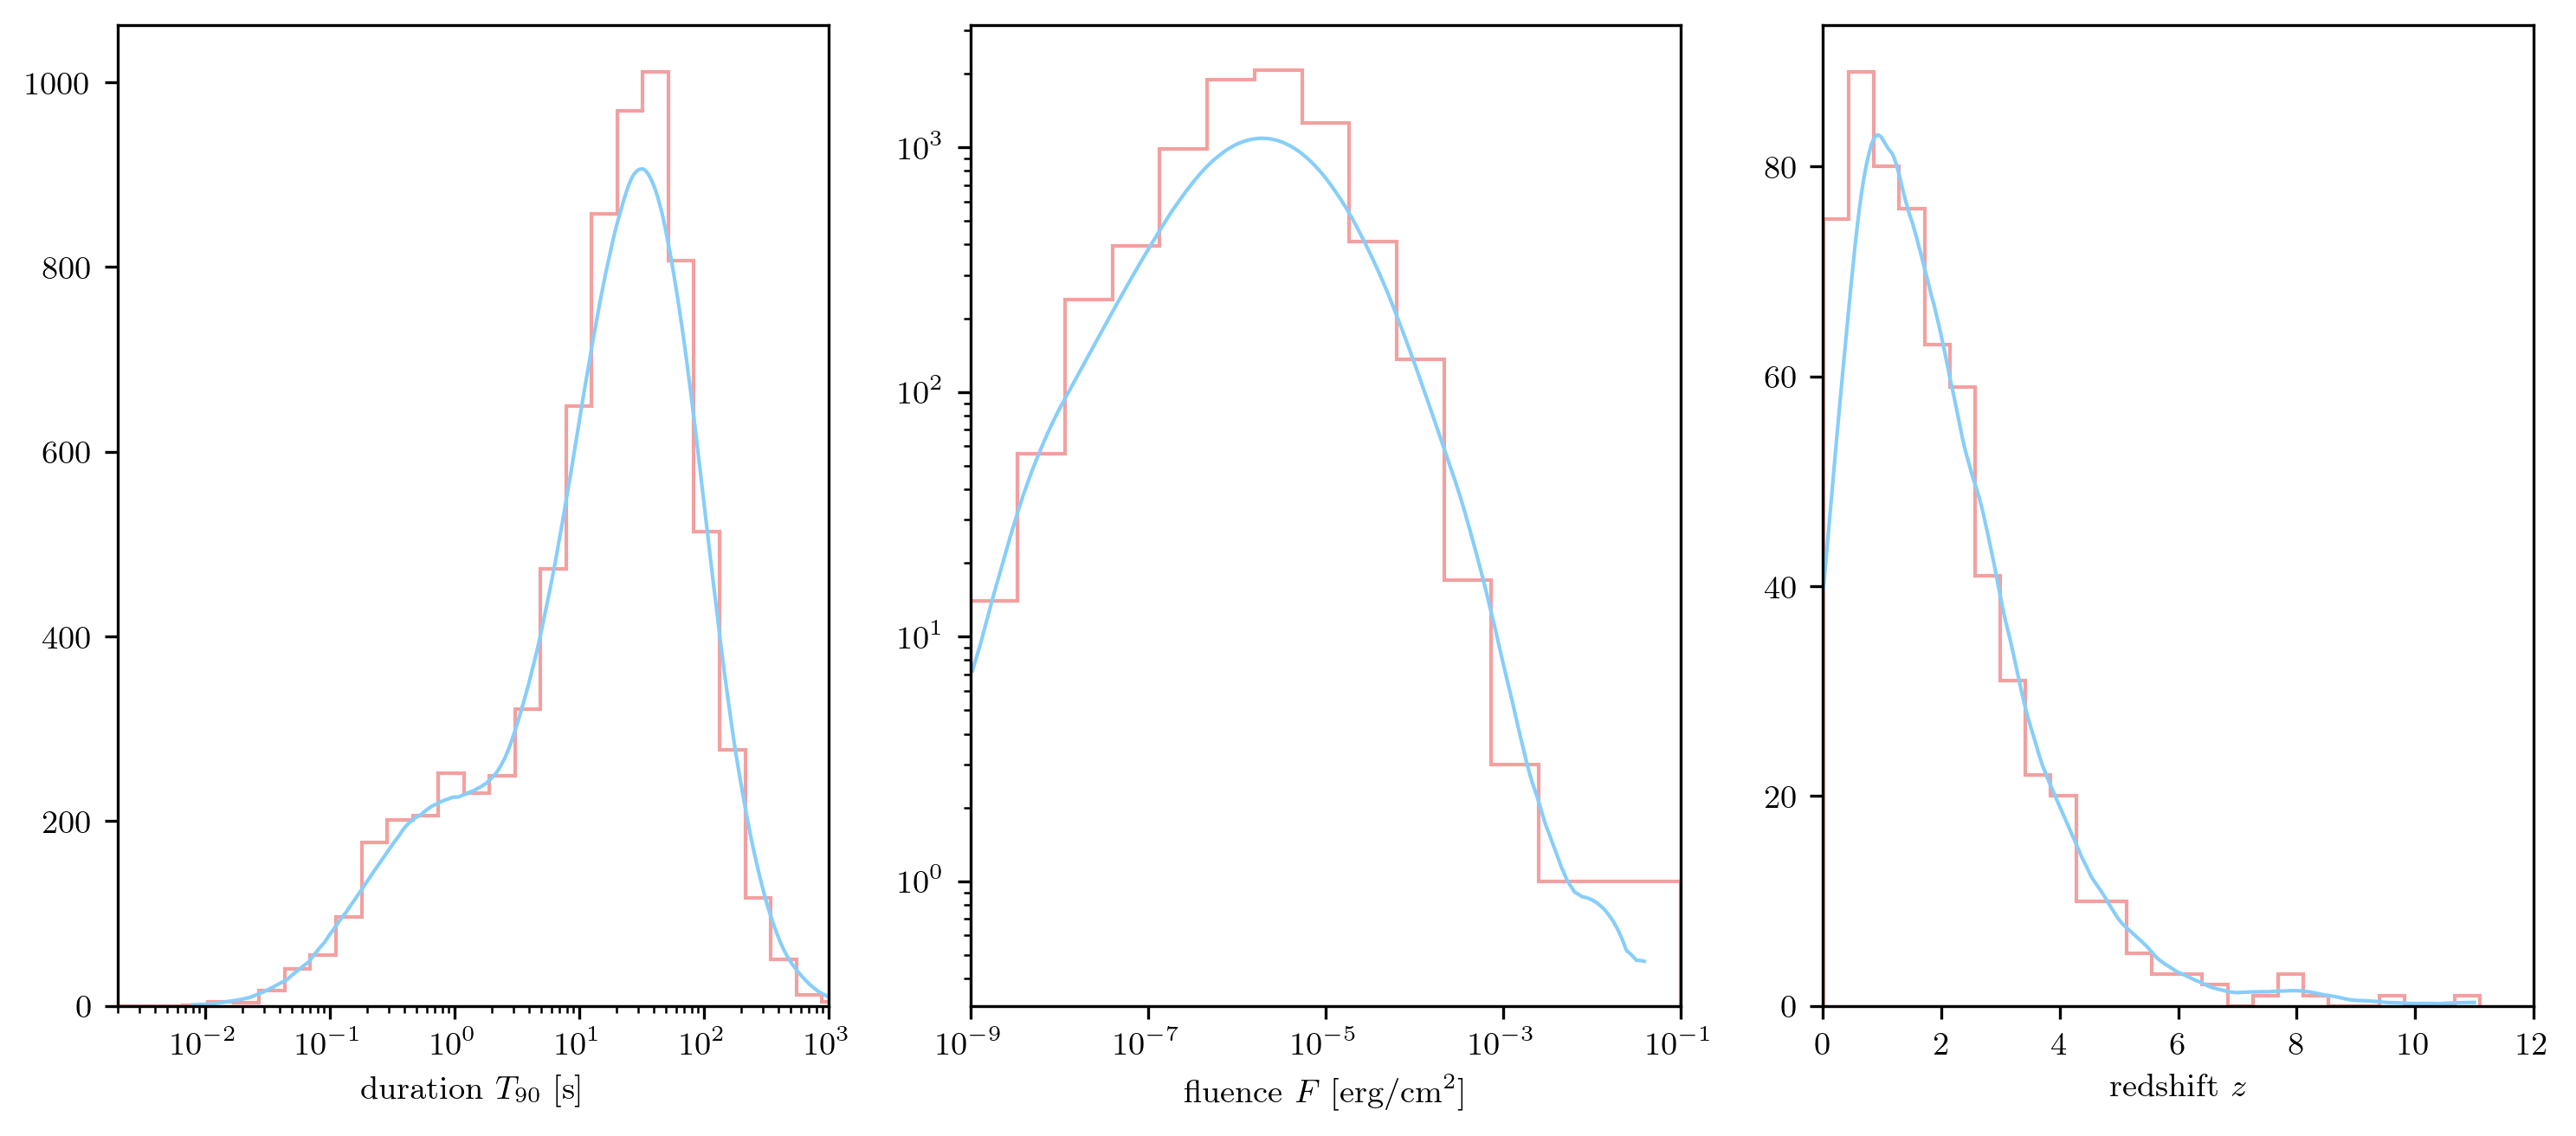

In [566]:
#-------------------------------------------------------------------------------------------
# Quick look at the data: some histograms
#-------------------------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(12,5))

normalize = False

#-------------------------------------------------------------------------------------------

ax[0].set_xlabel(r"duration $T_{90} \; [\textup{s}]$")
ax[0].set_xlim(2e-3,1e3)
ax[0].set_xscale('log')

_ = fancyhist(T, ax=ax[0], bins=np.logspace(-3,5,40), histtype="step", density=normalize, alpha=0.75, color='lightcoral')

PDF_T_KDE, T_KDE = KDE_sklearn_log(T, bandwidth=0.45, kernel="epanechnikov", density=normalize)
ax[0].plot(T_KDE, PDF_T_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

#-------------------------------------------------------------------------------------------

ax[1].set_xlabel(r"fluence $F \; [\textup{erg}/\textup{cm}^2]$")
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim(1e-9,1e-1)

_ = fancyhist(F[F>0], ax=ax[1], bins=np.logspace(-9,-1,16), histtype="step", density=normalize, alpha=0.75, color='lightcoral')

PDF_F_KDE, F_KDE = KDE_sklearn_log(F[F>0], bandwidth=1, kernel="epanechnikov", density=normalize)
ax[1].plot(F_KDE, PDF_F_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

#-------------------------------------------------------------------------------------------

ax[2].set_xlabel(r"redshift $z$")
ax[2].set_xlim(0,12)
_ = fancyhist(z[z>0], ax=ax[2], bins='freedman', histtype="step", density=normalize, alpha=0.75, color='lightcoral')

PDF_z_KDE, z_KDE = KDE_sklearn(z[z>0], bandwidth=1., kernel="epanechnikov", density=normalize)
ax[2].plot(z_KDE, PDF_z_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

# --------------------------------------------------------------------------------------
# Utility: legend, saving the figure...

# _ = ax[0].legend(loc=1,frameon=True, framealpha=1, fancybox=False, edgecolor='black')

# do we want to save the figure?
if False:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L14_images/L14_GRB_first_look_histograms.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L14_images/L14_GRB_first_look_histograms.pdf', bbox_inches='tight')


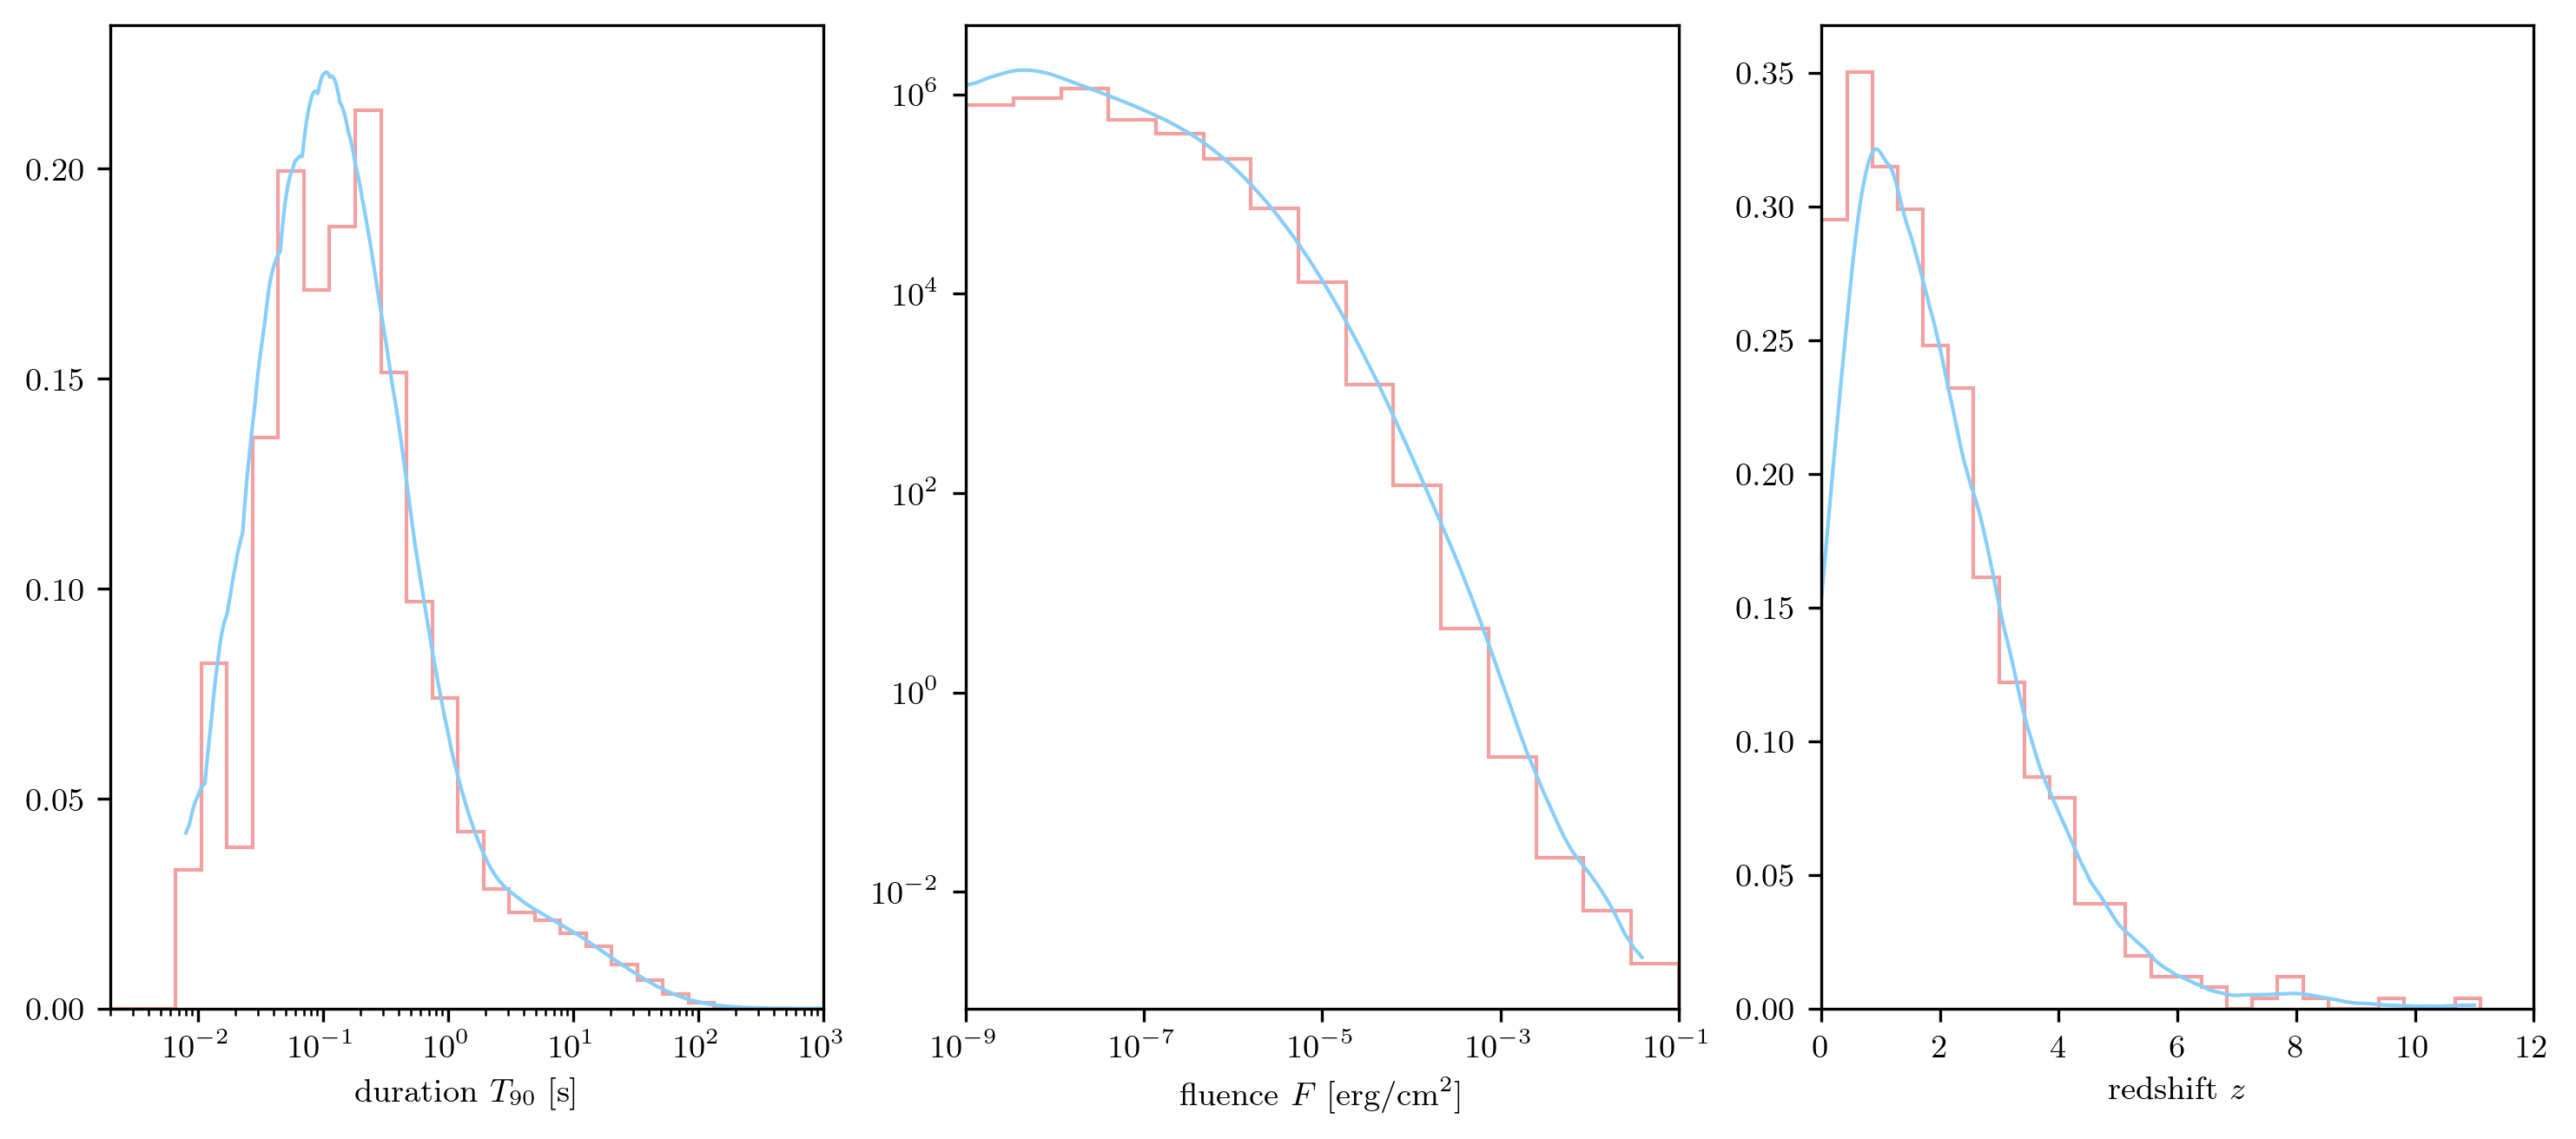

In [ ]:
#-------------------------------------------------------------------------------------------
# Quick look at the data: some histograms
#-------------------------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(12,5))

normalize = True

#-------------------------------------------------------------------------------------------

ax[0].set_xlabel(r"duration $T_{90} \; [\textup{s}]$")
ax[0].set_xlim(2e-3,1e3)
ax[0].set_xscale('log')

_ = fancyhist(T, ax=ax[0], bins=np.logspace(-3,5,40), histtype="step", density=normalize, alpha=0.75, color='lightcoral')

PDF_T_KDE, T_KDE = KDE_sklearn_log(T, bandwidth=0.45, kernel="epanechnikov", density=normalize)
ax[0].plot(T_KDE, PDF_T_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

#-------------------------------------------------------------------------------------------

ax[1].set_xlabel(r"fluence $F \; [\textup{erg}/\textup{cm}^2]$")
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim(1e-9,1e-1)

_ = fancyhist(F[F>0], ax=ax[1], bins=np.logspace(-9,-1,16), histtype="step", density=normalize, alpha=0.75, color='lightcoral')

PDF_F_KDE, F_KDE = KDE_sklearn_log(F[F>0], bandwidth=1, kernel="epanechnikov", density=normalize)
ax[1].plot(F_KDE, PDF_F_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

#-------------------------------------------------------------------------------------------

ax[2].set_xlabel(r"redshift $z$")
ax[2].set_xlim(0,12)
_ = fancyhist(z[z>0], ax=ax[2], bins='freedman', histtype="step", density=normalize, alpha=0.75, color='lightcoral')

PDF_z_KDE, z_KDE = KDE_sklearn(z[z>0], bandwidth=1., kernel="epanechnikov", density=normalize)
ax[2].plot(z_KDE, PDF_z_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

# --------------------------------------------------------------------------------------
# Utility: legend, saving the figure...

# _ = ax[0].legend(loc=1,frameon=True, framealpha=1, fancybox=False, edgecolor='black')

# do we want to save the figure?
if False:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L14_images/L14_GRB_first_look_histograms_normalized.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L14_images/L14_GRB_first_look_histograms_normalized.pdf', bbox_inches='tight')


From the T90 histogram and kernel density estimator, it looks like there are two populations of $\gamma$-ray bursts: one with shorter durations peaking around 0.1s, and one with longer durations peaking around 30s. 

Let us therefore try to use a classifier to find two clusters in  the duration space. 

Let us also try to fit the T90 histogram with a gaussian mixture with 2 components. 


k-means centres: 0.91 , 33.19

Gaussian centres: 0.97 , 30.71


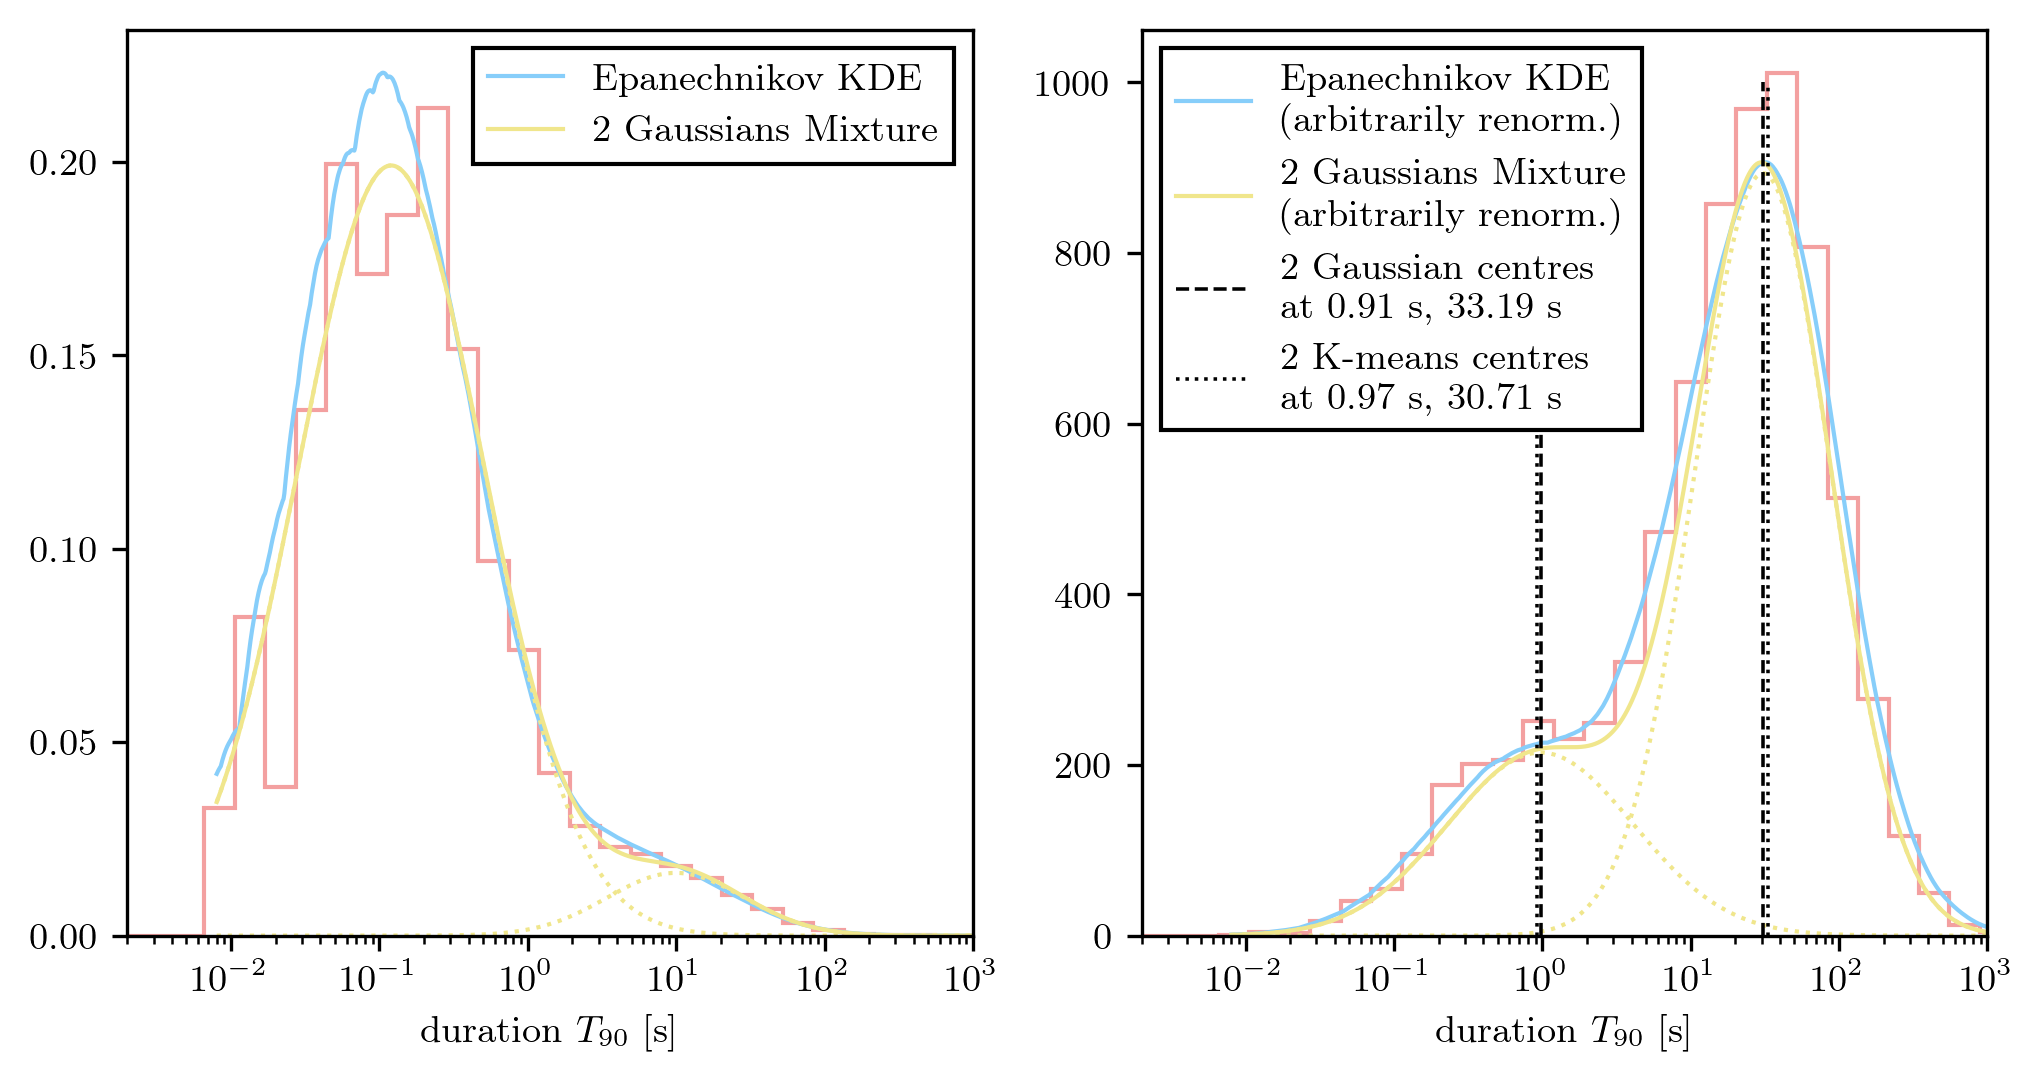

In [571]:
logT_sklearn = np.log10(T)[:, np.newaxis]

#-------------------------------------------------------------------------------------------
# K-means clustering with 2 clusters

centres_kmeans, labels_kmeans = Kmeans_log(T, nclusters=2)
print('\nk-means centres: {:.2f} , {:.2f}'.format(centres_kmeans[0],centres_kmeans[1]))

#-------------------------------------------------------------------------------------------
# gaussian mixture with 2 componensts

PDF_T_2G, T_2G , T_2G_means, T_2G_respons , PDF_T_2G_c1, PDF_T_2G_c2 = TwoGaussians_log(T, n_components=2, n_init=25)
print('\nGaussian centres: {:.2f} , {:.2f}'.format(T_2G_means[0],T_2G_means[1]))

#-------------------------------------------------------------------------------------------

fig , ax = plt.subplots(1,2,figsize=(8,4))

for i in [0,1]:
    ax[i].set_xlabel(r"duration $T_{90} \; [\textup{s}]$")
    ax[i].set_xlim(2e-3,1e3)
    ax[i].set_xscale('log')

#-------------------------------------------------------------------------------------------
# histogram for T90 (normalized)

_ = fancyhist(T, ax=ax[0], bins=np.logspace(-3,5,40), histtype="step", density=True, alpha=0.75, color='lightcoral')

PDF_T_KDE, T_KDE = KDE_sklearn_log(T, bandwidth=0.45, kernel="epanechnikov", density=True)
ax[0].plot(T_KDE, PDF_T_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE')

ax[0].plot(T_2G, PDF_T_2G, ls='-', lw=1, color='khaki', label='2 Gaussians Mixture')
ax[0].plot(T_2G, PDF_T_2G_c1, ls=':', lw=1, color='khaki')
ax[0].plot(T_2G, PDF_T_2G_c2, ls=':', lw=1, color='khaki')

#-------------------------------------------------------------------------------------------
# histogram for T90 (not normalized)

_ = fancyhist(T, ax=ax[1], bins=np.logspace(-3,5,40), histtype="step", density=False, alpha=0.75, color='lightcoral')

PDF_T_KDE, T_KDE = KDE_sklearn_log(T, bandwidth=0.45, kernel="epanechnikov", density=False)
ax[1].plot(T_KDE, PDF_T_KDE, ls='-', lw=1, color='lightskyblue', label='Epanechnikov KDE'+ '\n(arbitrarily renorm.)')

PDF_T_2G_nn, T_2G_nn , _ , _ , PDF_T_2G_c1_nn, PDF_T_2G_c2_nn = TwoGaussians_log(T, n_components=2, n_init=25, density=False)
ax[1].plot(T_2G_nn, PDF_T_2G_nn, ls='-', lw=1, color='khaki', label='2 Gaussians Mixture'+ '\n(arbitrarily renorm.)')
ax[1].plot(T_2G_nn, PDF_T_2G_c1_nn, ls=':', lw=1, color='khaki')
ax[1].plot(T_2G_nn, PDF_T_2G_c2_nn, ls=':', lw=1, color='khaki')

ax[1].vlines(T_2G_means, ymin=0, ymax=1e3, colors='black', ls='--', lw=0.85, label='2 Gaussian centres' + '\nat {:.2f} s, {:.2f} s'.format(centres_kmeans[0],centres_kmeans[1]))    # ymax=0.25 if normalized, otherwise 1e3

ax[1].vlines(centres_kmeans, ymin=0, ymax=1e3, colors='black', ls=':', lw=0.85, label='2 K-means centres' + '\nat {:.2f} s, {:.2f} s'.format(T_2G_means[0],T_2G_means[1]))   # ymax=0.25 if normalized, otherwise 1e3

#-------------------------------------------------------------------------------------------

for i, loc in zip([0,1],[1,2]):
    _ = ax[i].legend(loc=loc, frameon=True, framealpha=1, fancybox=False, edgecolor='black')

# do we want to save the figure?
if False:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L14_images/L14_GRB_T_histogram__KDE_and_2G.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L14_images/L14_GRB_T_histogram__KDE_and_2G.pdf', bbox_inches='tight')




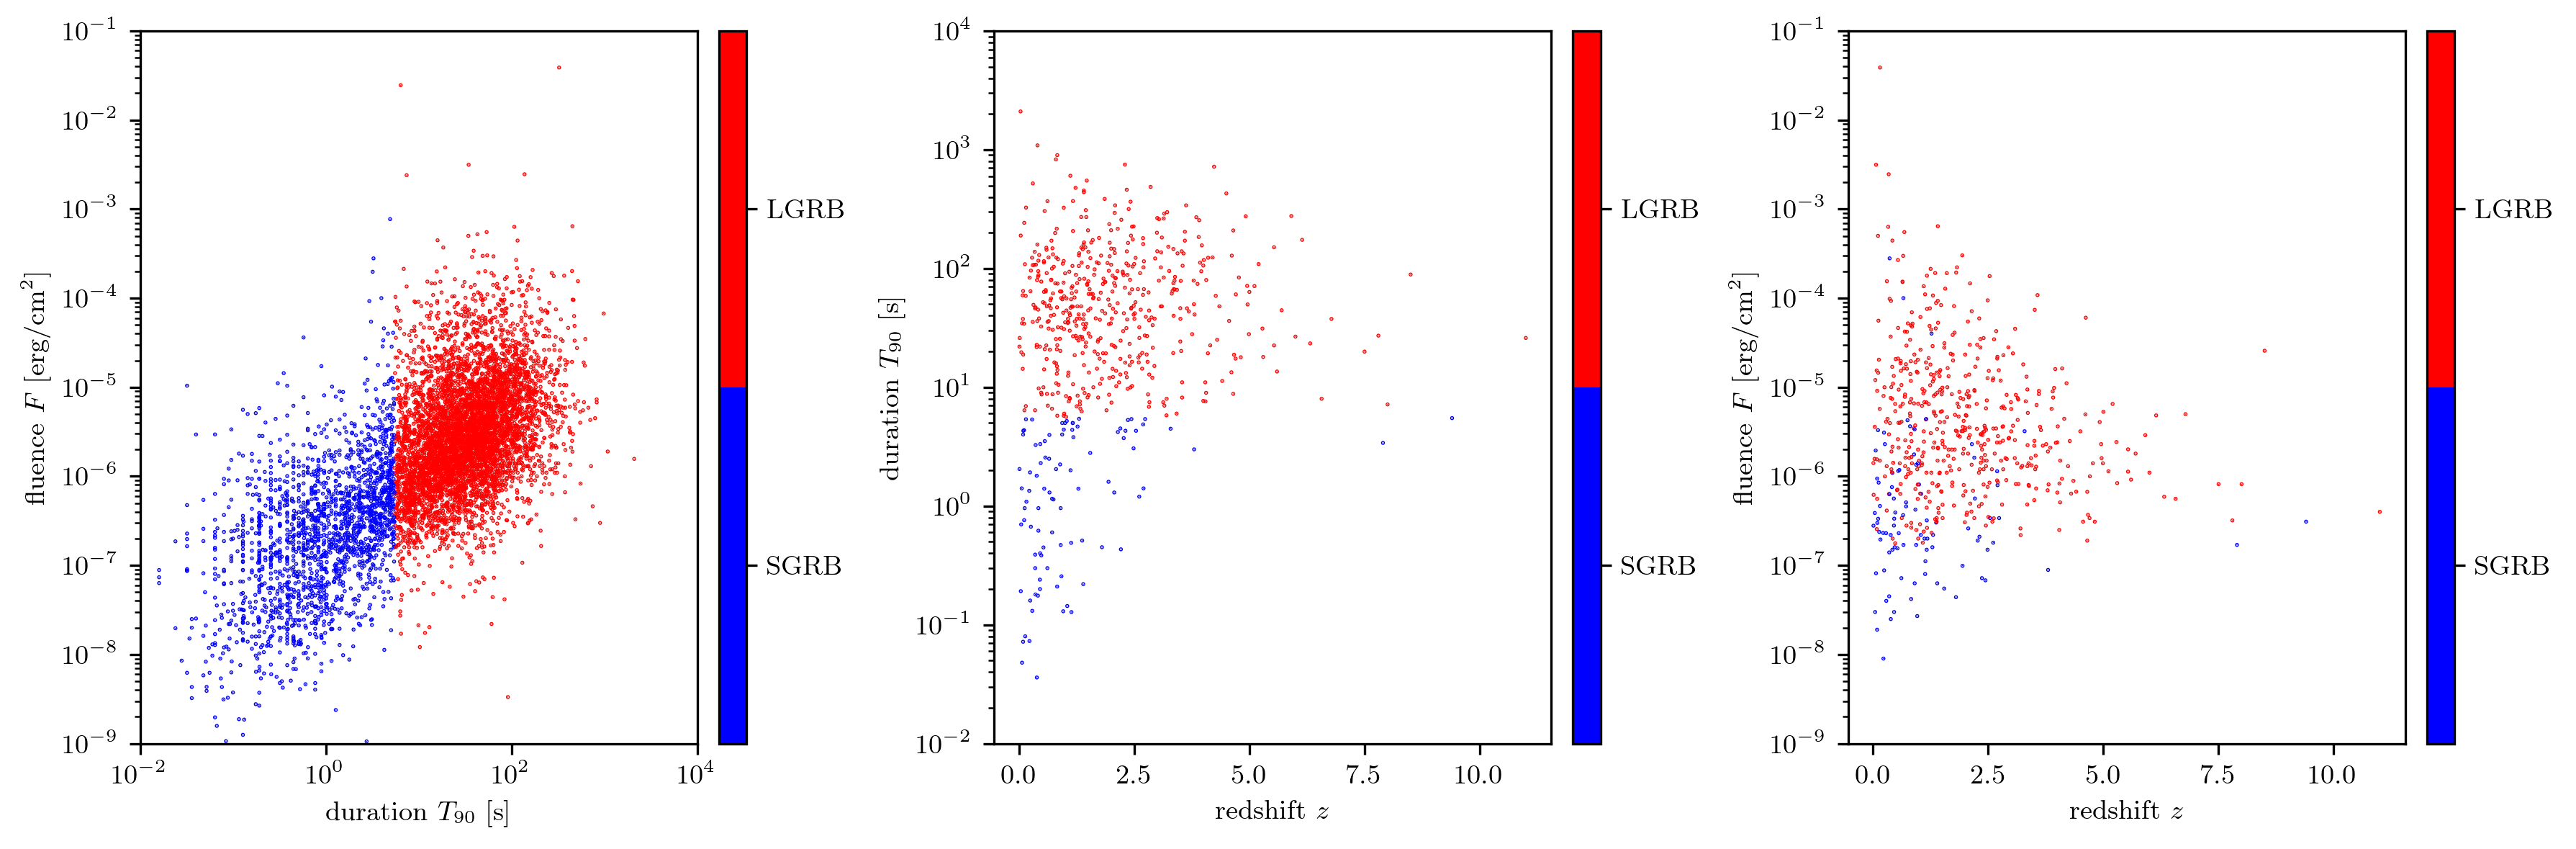

In [ ]:
#-------------------------------------------------------------------------------------------
# clustered data in T: scatter-plots (T-F), (z-T), (z-F)
#-------------------------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(12,4))

#-------------------------------------------------------------------------
# define a discrete colormap for the two clusters

cmap   = mpl.cm.bwr   # diverging cmaps: PiYG, seismic; uniform looking cmaps: magma, plasma
cmapl  = [cmap(i) for i in range(cmap.N)]
cmap   = mpl.colors.LinearSegmentedColormap.from_list('Custom cmap', cmapl, cmap.N)
bounds = np.linspace(-0.5, 1.5, 3)
ticks  = np.linspace(0., 1., 2)
tlabs  = ['SGRB','LGRB']
norm   = mpl.colors.BoundaryNorm(bounds, cmap.N)

#-------------------------------------------------------------------------

ax[0].set_xlabel(r"duration $T_{90} \; [\textup{s}]$")
ax[0].set_xlim(1e-2,1e4)
ax[0].set_xscale('log')
ax[0].set_ylabel(r"fluence $F \; [\textup{erg}/\textup{cm}^2]$")
ax[0].set_ylim(1e-9,1e-1)
ax[0].set_yscale('log')

ax[0].scatter(T, F, c=labels_kmeans, s=0.1, cmap=cmap, norm=norm)

#-------------------------------------------------------------------------------------------

ax[1].set_xlabel(r"redshift $z$")
ax[1].set_ylabel(r"duration $T_{90} \; [\textup{s}]$")
ax[1].set_ylim(1e-2,1e4)
ax[1].set_yscale('log')

ax[1].scatter(z[z>0], T[z>0], c=labels_kmeans[z>0], s=0.1, cmap=cmap, norm=norm)

#-------------------------------------------------------------------------------------------

ax[2].set_xlabel(r"redshift $z$")
ax[2].set_ylabel(r"fluence $F \; [\textup{erg}/\textup{cm}^2]$")
ax[2].set_ylim(1e-9,1e-1)
ax[2].set_yscale('log')

ax[2].scatter(z[z>0], F[z>0], c=labels_kmeans[z>0], s=0.1, cmap=cmap, norm=norm)

# --------------------------------------------------------------------------------------
# plot colorbars with clustering labels

for i in range(3):
    divid  = make_axes_locatable(ax[i])
    cmapax = divid.append_axes('right', size='5%', pad=0.10)
    cbar   = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=norm, spacing='proportional', ticks=ticks, boundaries=bounds, format='%1i')
    cbar.ax.set_yticklabels(tlabs)

# --------------------------------------------------------------------------------------
# Utility: legend, saving the figure...

if False:
    for i in range(3):
        _ = ax[i].legend(loc=1,frameon=True, framealpha=1, fancybox=False, edgecolor='black')

fig.tight_layout()

# do we want to save the figure?
if False:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L14_images/L14_GRB_first_look_plots.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L14_images/L14_GRB_first_look_plots.pdf', bbox_inches='tight')


In [551]:
_ = '''
z  = z[F>0]
ra = ra[F>0]
de = de[F>0]
ep = ep[F>0]
eT = eT[F>0]
T  = T[F>0]
eF = eF[F>0]
F  = F[F>0]

ra = ra[z>0]
de = de[z>0]
ep = ep[z>0]
eT = eT[z>0]
T  = T [z>0]
eF = eF[z>0]
F  = F [z>0]
z  = z [z>0]

'''

In [405]:
#-------------------------------------------------------------------------
# reduction of the dimensionality of the dataset: 
# try Isomap to find a D=2 surface embedded in D=3
#-------------------------------------------------------------------------

data = np.array([T,F,z])
print(data.shape)
print(data.T.shape)

embedding = Isomap(n_components=2)
reduced_data = embedding.fit_transform(data.T).T

#-------------------------------------------------------------------------
# reduction of the dimensionality of the dataset: 
# try PCA to find Principal Components 
#-------------------------------------------------------------------------

pca = PCA(n_components=2)
pca_data = pca.fit_transform(data.T).T

#-------------------------------------------------------------------------

(3, 7592)
(7592, 3)


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 186 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\sparse\_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\sparse\_index.py:82: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_int

PCA projection of the 2 components:
0.043 x $T_{90}$ + 0.011 x $F$ + 0.999 x $z$
-0.006 x $T_{90}$ + 1.000 x $F$ + -0.011 x $z$


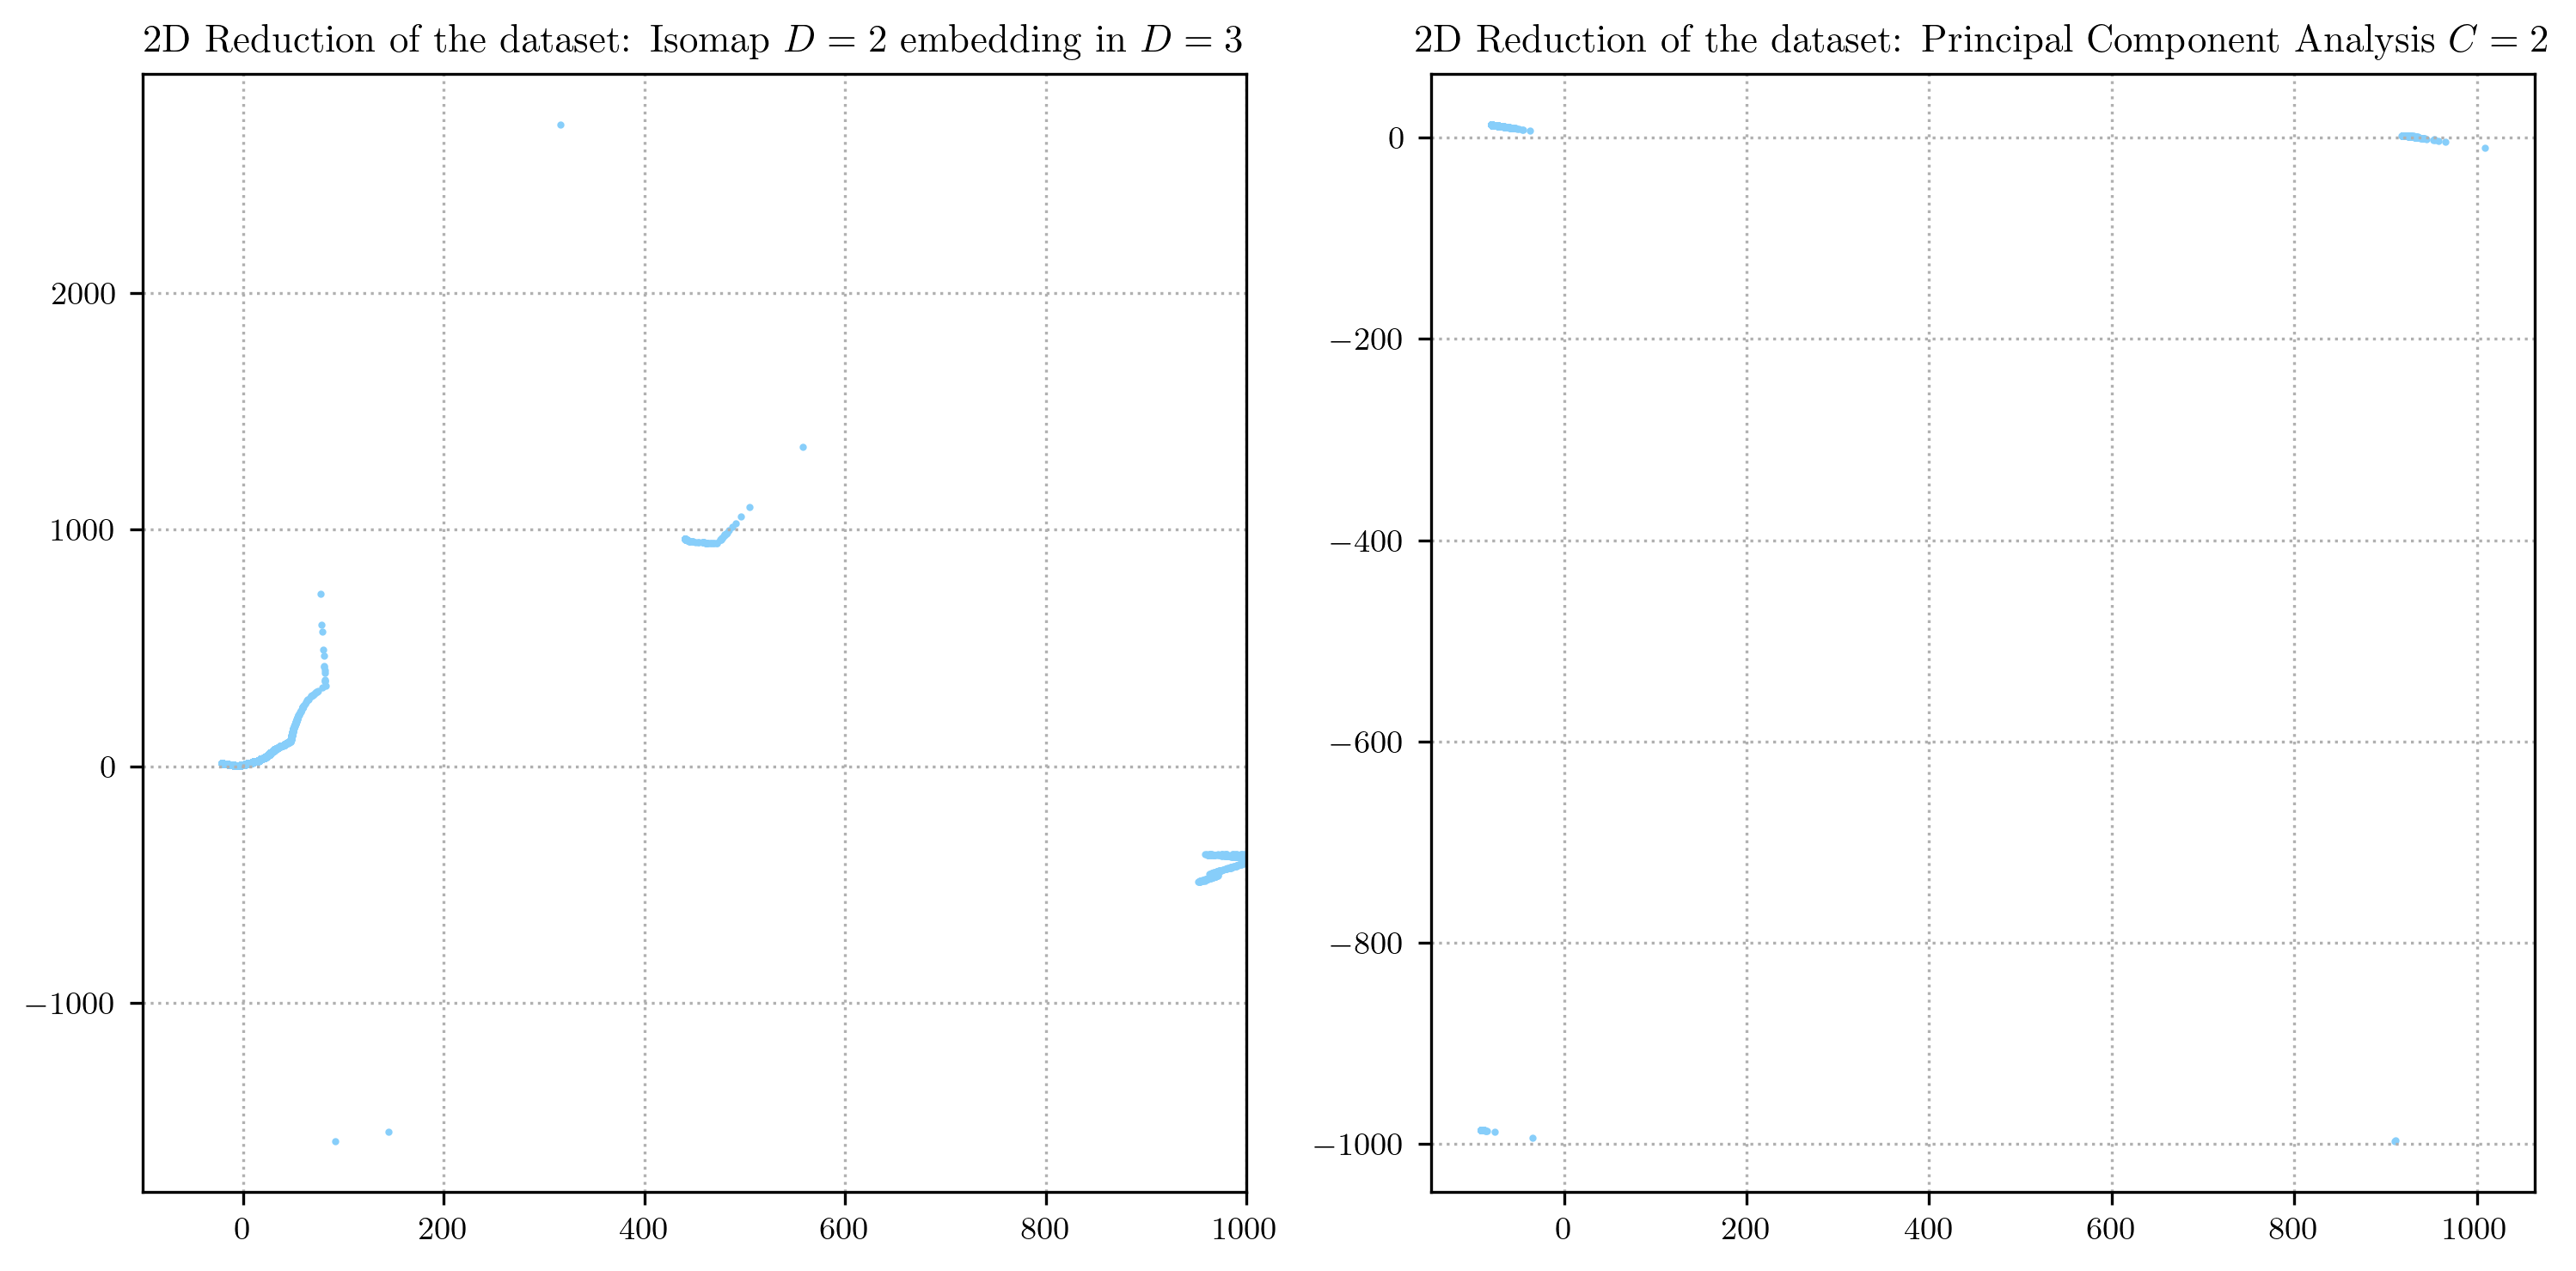

In [406]:
#-------------------------------------------------------------------------
# Plot the D=2 reduction of the D=3 dataset
# NOTE: we haven't clustered the data yet
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,2,figsize=(10,5))

#-------------------------------------------------------------------------

ax[0].grid(ls=':')
ax[0].set_xlim(-1e2,1e3)
ax[0].set_title('2D Reduction of the dataset: Isomap $D=2$ embedding in $D=3$')
leplot_isomap = ax[0].scatter( reduced_data[0], reduced_data[1], c='lightskyblue', s=1)

#-------------------------------------------------------------------------

ax[1].grid(ls=':')
ax[1].set_title('2D Reduction of the dataset: Principal Component Analysis $C=2$')
leplot_pca = ax[1].scatter( pca_data[0], pca_data[1], c='lightskyblue', s=1)

print("PCA projection of the 2 components:")
for component in pca.components_:
    print(" + ".join("%.3f x %s" % (value, name) for value, name in zip(component, [r'$T_{90}$', r'$F$', r'$z$'])))


#-------------------------------------------------------------------------
# savefig and additional notes

fig.tight_layout()

# do we want to save the figure?
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L14_images/L14_GRB_first_look_reduced_dim.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L14_images/L14_GRB_first_look_reduced_dim.pdf', bbox_inches='tight')

#-------------------------------------------------------------------------